In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("CAR DETAILS.csv")
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [3]:
df.columns = df.columns.str.strip()

df['car_age'] = 2026 - df['year']

df = df.drop('name', axis=1)
df.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,car_age
0,2007,60000,70000,Petrol,Individual,Manual,First Owner,19
1,2007,135000,50000,Petrol,Individual,Manual,First Owner,19
2,2012,600000,100000,Diesel,Individual,Manual,First Owner,14
3,2017,250000,46000,Petrol,Individual,Manual,First Owner,9
4,2014,450000,141000,Diesel,Individual,Manual,Second Owner,12


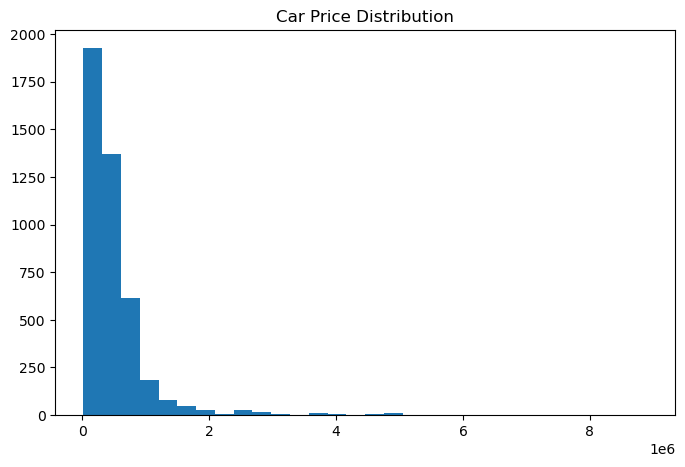

In [4]:
plt.figure(figsize=(8,5))
plt.hist(df['selling_price'], bins=30)
plt.title("Car Price Distribution")
plt.show()

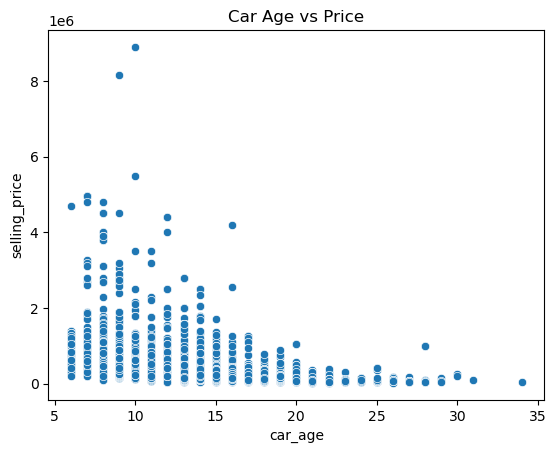

In [5]:
sns.scatterplot(x=df['car_age'], y=df['selling_price'])
plt.title("Car Age vs Price")
plt.show()

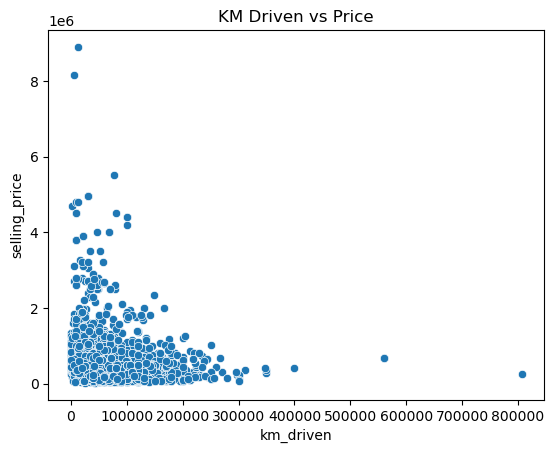

In [6]:
sns.scatterplot(x=df['km_driven'], y=df['selling_price'])
plt.title("KM Driven vs Price")
plt.show()

In [7]:
df = pd.get_dummies(df, drop_first=True)

In [8]:
from sklearn.model_selection import train_test_split

X = df.drop('selling_price', axis=1)
y = df['selling_price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, pred))

R2 Score: 0.4949121403232528
